<a href="https://colab.research.google.com/github/saramarrapesa/DL_miniLLaVA/blob/main/mini_LLaVA_MLPV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Librerie base
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import os
import json
import random
import gc

#import per il Vision Transformer
from transformers import (
    CLIPVisionModel,
    CLIPProcessor,
    AutoTokenizer,
    AutoModelForCausalLM,
    )

#import per LoRA
from peft import LoraConfig, get_peft_model, PeftModel

#import Dataset e immagini
from datasets import load_from_disk
from PIL import Image

# **Modello per la Fase 1**
Allineamento delle Features

In [ ]:
class MiniLLaVA_V2_Fase1(nn.Module):
    def __init__(self, model_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0"):
        super().__init__()

        # 1. VISION ENCODER (B/16) - Completamente congelato per la Fase 1
        self.vision_encoder = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch16")
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

        # 2. LLM (TinyLlama) - Congelato per la Fase 1 (usiamo solo i suoi embeddings)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.llm = AutoModelForCausalLM.from_pretrained(model_id)
        for param in self.llm.parameters():
            param.requires_grad = False

        # 3. Proiettore MLP
        self.mm_projector = nn.Sequential(
            nn.Linear(768, 2048),
            nn.GELU(),
            nn.Linear(2048, 2048)
        )

    def forward(self, input_ids, pixel_values, labels=None, attention_mask=None):
        # Estrazione feature visive
        with torch.no_grad():
            zv = self.vision_encoder(pixel_values).last_hidden_state

        # Proiezione attraverso MLP
        hv = self.mm_projector(zv)

        # Embeddings del testo
        inputs_embeds = self.llm.get_input_embeddings()(input_ids)

        # Unione Multimodale
        combined_embeds = torch.cat((hv, inputs_embeds), dim=1)

        # Maschera di attenzione (197 token visivi + token testo)
        visual_mask = torch.ones((attention_mask.shape[0], hv.shape[1]), device=attention_mask.device)
        combined_mask = torch.cat((visual_mask, attention_mask), dim=1)

        if labels is not None:
            # Le etichette per la parte visiva sono -100 (da ignorare nel calcolo della Loss)
            ignore_labels = torch.full((labels.shape[0], hv.shape[1]), -100, device=labels.device)
            combined_labels = torch.cat((ignore_labels, labels), dim=1)
            return self.llm(inputs_embeds=combined_embeds, attention_mask=combined_mask, labels=combined_labels)

        return self.llm(inputs_embeds=combined_embeds, attention_mask=combined_mask)

# Inizializzazione
model_v2_stage1 = MiniLLaVA_V2_Fase1().to("cuda")
print("Modello V2 (B/16 + MLP) pronto per la Fase 1!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Modello V2 (B/16 + MLP) pronto per la Fase 1!


# **Dataset**



In [ ]:
from datasets import load_from_disk
import os

drive_path = "/content/drive/MyDrive/miniLLava_v2/Dataset"

if os.path.exists(drive_path):
    dataset_coco = load_from_disk(drive_path)
    print(f"Dataset pronto! Numero esempi: {len(dataset_coco)}")
else:
    print(f"Errore: Il percorso {drive_path} non esiste.")

Dataset pronto! Numero esempi: 20000


In [ ]:
#Creo la mappa degli ID
# Creiamo l'indice rapido per evitare crash di RAM
column_id = 'id' if 'id' in dataset_coco.column_names else 'image_id'

coco_id_to_idx = {str(item[column_id]).zfill(12): i for i, item in enumerate(dataset_coco)}
print(f"Indice creato: {len(coco_id_to_idx)} immagini mappate.")

Indice creato: 20000 immagini mappate.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class AlignmentDataset(Dataset):
    def __init__(self, coco_ds, id_map, processor, tokenizer, max_samples=20000):
        self.coco_ds = coco_ds
        self.id_map = id_map
        self.processor = processor
        self.tokenizer = tokenizer
        # Lista di tutti gli ID disponibili nel nostro subset
        self.ids = list(id_map.keys())[:max_samples]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        img_idx = self.id_map[image_id]

        # 1. Recupero Immagine
        item = self.coco_ds[img_idx]
        image = item['image'].convert("RGB")

        # 2. Recupero Didascalia
        caption = item.get('caption', item.get('text', "Descrivi questa immagine."))

        # Formattazione semplice per l'allineamento con solo la didascalia
        prompt = f"{caption}</s>"

        return {"image": image, "prompt": prompt}

# Funzione per creare i Batch
def collate_alignment(batch):
    images = [b['image'] for b in batch]
    prompts = [b['prompt'] for b in batch]

    pixel_values = model_v2_stage1.processor(images=images, return_tensors="pt").pixel_values
    tokens = model_v2_stage1.tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=64
    )

    return {
        'pixel_values': pixel_values.to("cuda"),
        'input_ids': tokens.input_ids.to("cuda"),
        'attention_mask': tokens.attention_mask.to("cuda"),
        'labels': tokens.input_ids.to("cuda") # In questa fase prediciamo la didascalia stessa
    }

# Creazione del DataLoader
train_ds_alignment = AlignmentDataset(
    coco_ds=dataset_coco,
    id_map=coco_id_to_idx,
    processor=model_v2_stage1.processor,
    tokenizer=model_v2_stage1.tokenizer,
    max_samples=20000
)

print(f"AlignmentDataset configurato con {len(train_ds_alignment)} campioni.")
train_loader = DataLoader(train_ds_alignment, batch_size=8, shuffle=True, collate_fn=collate_alignment)

print(f"DataLoader Fase 1 pronto con {len(train_ds_alignment)} campioni.")

AlignmentDataset configurato con 20000 campioni.
DataLoader Fase 1 pronto con 20000 campioni.


# **Training proiettore MLP**

In [ ]:
# 1. Preparazione Modello e Ottimizzatore
model_v2_stage1 = model_v2_stage1.to(torch.float32).to("cuda") # Converte in Float32 e sposta su GPU
model_v2_stage1.train()

# Ottimizziamo solo il nuovo proiettore MLP (nn.Sequential)
optimizer = torch.optim.AdamW(model_v2_stage1.mm_projector.parameters(), lr=1e-3)

epochs = 1

print("Inizio Allineamento Feature V2 ...")
for epoch in range(epochs):
    for i, batch in enumerate(train_loader):
        optimizer.zero_grad()

        batch = {k: v.to("cuda") if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        # Forward pass
        outputs = model_v2_stage1(**batch)
        loss = outputs.loss

        # Backward
        loss.backward()
        optimizer.step()

        if i % 50 == 0:
            print(f"Epoch {epoch} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

# Salvo i pesi del nuovo MLP
path_salvataggio = "/content/drive/MyDrive/mini_llava_projector_v2_b16.bin"
torch.save(model_v2_stage1.mm_projector.state_dict(), path_salvataggio)

print("-" * 30)
print(f"Allineamento V2 completato!")
print(f"Pesi salvati in: {path_salvataggio}")

Inizio Allineamento Feature V2 ...
Epoch 0 | Batch 0/2500 | Loss: 6.6204
Epoch 0 | Batch 50/2500 | Loss: 2.5436
Epoch 0 | Batch 100/2500 | Loss: 2.1679
Epoch 0 | Batch 150/2500 | Loss: 2.2670
Epoch 0 | Batch 200/2500 | Loss: 2.3033
Epoch 0 | Batch 250/2500 | Loss: 1.9065
Epoch 0 | Batch 300/2500 | Loss: 2.0685
Epoch 0 | Batch 350/2500 | Loss: 2.0043
Epoch 0 | Batch 400/2500 | Loss: 1.8808
Epoch 0 | Batch 450/2500 | Loss: 2.0408
Epoch 0 | Batch 500/2500 | Loss: 1.9820
Epoch 0 | Batch 550/2500 | Loss: 1.8284
Epoch 0 | Batch 600/2500 | Loss: 1.8365
Epoch 0 | Batch 650/2500 | Loss: 1.8348
Epoch 0 | Batch 700/2500 | Loss: 1.5288
Epoch 0 | Batch 750/2500 | Loss: 2.1560
Epoch 0 | Batch 800/2500 | Loss: 1.8216
Epoch 0 | Batch 850/2500 | Loss: 1.6277
Epoch 0 | Batch 900/2500 | Loss: 1.9744
Epoch 0 | Batch 950/2500 | Loss: 1.9486
Epoch 0 | Batch 1000/2500 | Loss: 1.9018
Epoch 0 | Batch 1050/2500 | Loss: 1.9799
Epoch 0 | Batch 1100/2500 | Loss: 1.9716
Epoch 0 | Batch 1150/2500 | Loss: 2.0014
Epoc

# **Modello per la Fase 2**
Visual Instruction Tuning

In [ ]:
import torch
import torch.nn as nn
from transformers import CLIPVisionModel, CLIPProcessor, AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

class MiniLLaVA_V2_Fase2(nn.Module):
    def __init__(self, model_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0", mlp_path=None):
        super().__init__()

        # 1. VISION ENCODER (B/16)
        self.vision_encoder = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch16")
        for param in self.vision_encoder.parameters():
            param.requires_grad = False

        # SBLOCCO ULTIMO LAYER DI CLIP
        for param in self.vision_encoder.vision_model.encoder.layers[-1].parameters():
            param.requires_grad = True

        self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

        # 2. LLM (TinyLlama + LoRA)
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        raw_llm = AutoModelForCausalLM.from_pretrained(model_id)

        lora_config = LoraConfig(
            r=16, lora_alpha=32, target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
            lora_dropout=0.05, task_type="CAUSAL_LM"
        )
        self.llm = get_peft_model(raw_llm, lora_config)

        # 3. PROIETTORE MLP
        self.mm_projector = nn.Sequential(
            nn.Linear(768, 2048),
            nn.GELU(),
            nn.Linear(2048, 2048)
        )

        if mlp_path:
            self.mm_projector.load_state_dict(torch.load(mlp_path))

    def forward(self, input_ids, pixel_values, labels=None, attention_mask=None):
        zv = self.vision_encoder(pixel_values).last_hidden_state
        hv = self.mm_projector(zv)
        inputs_embeds = self.llm.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat((hv, inputs_embeds), dim=1)

        visual_mask = torch.ones((attention_mask.shape[0], hv.shape[1]), device=attention_mask.device)
        combined_mask = torch.cat((visual_mask, attention_mask), dim=1)

        if labels is not None:
            ignore_labels = torch.full((labels.shape[0], hv.shape[1]), -100, device=labels.device)
            combined_labels = torch.cat((ignore_labels, labels), dim=1)
            return self.llm(inputs_embeds=combined_embeds, attention_mask=combined_mask, labels=combined_labels)

        return self.llm(inputs_embeds=combined_embeds, attention_mask=combined_mask)

mlp_path = "/content/drive/MyDrive/miniLLava_v2/mini_llava_projector_v2_b16.bin"
model_v2_fase2 = MiniLLaVA_V2_Fase2(mlp_path=mlp_path).to("cuda")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight    

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
# Attiva il gradient checkpointing sul modello base dentro PEFT
model_v2_fase2.llm.base_model.model.gradient_checkpointing_enable()

# Disattiva la cache
model_v2_fase2.llm.base_model.model.config.use_cache = False



In [ ]:
import json
from torch.utils.data import Dataset, DataLoader

# 1. Carichiamo il file JSON con le istruzioni
json_path = '/content/drive/MyDrive/miniLLava_v2/LLaVA_Data/llava_instruct_150k.json'

try:
    with open(json_path, 'r') as f:
        llava_instruct_data = json.load(f)
    print(f"File JSON caricato: {len(llava_instruct_data)} conversazioni totali.")
except FileNotFoundError:
    print(f"Errore: File JSON non trovato in {json_path}. Modifica il percorso se necessario!")

# 2. Creiamo la classe per il Dataset di Fase 2
class InstructDataset(Dataset):
    def __init__(self, json_data, coco_ds, id_map, processor, tokenizer, max_samples=10000):
        self.valid_data = []

        for item in json_data:
            image_id = str(item.get('image'))
            clean_id = image_id.split('.')[0]

            if clean_id in id_map:
                item['clean_id'] = clean_id
                self.valid_data.append(item)

            if len(self.valid_data) >= max_samples:
                break

        self.coco_ds = coco_ds
        self.id_map = id_map
        self.processor = processor
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.valid_data)

    def __getitem__(self, idx):
        item = self.valid_data[idx]
        image_id = item['clean_id']

        img_idx = self.id_map[image_id]
        image = self.coco_ds[img_idx]['image'].convert("RGB")

        user_text = item['conversations'][0]['value'].replace("<image>\n", "").replace("\n<image>", "")
        assistant_text = item['conversations'][1]['value']

        prompt = f"<|user|>\n{user_text}</s>\n<|assistant|>\n{assistant_text}</s>"
        return {"image": image, "prompt": prompt}

# 3. Funzione per creare i batch
def collate_instruct(batch):
    images = [b['image'] for b in batch]
    prompts = [b['prompt'] for b in batch]

    pixel_values = model_v2_fase2.processor(images=images, return_tensors="pt").pixel_values

    # Aumentiamo la max_length perché le risposte ora sono discorsi articolati, non più didascalie
    tokens = model_v2_fase2.tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )

    return {
        'pixel_values': pixel_values.to("cuda").to(torch.float32),
        'input_ids': tokens.input_ids.to("cuda"),
        'attention_mask': tokens.attention_mask.to("cuda"),
        'labels': tokens.input_ids.to("cuda")
    }

# 4. Inizializziamo Dataset e DataLoader
train_ds_instruct = InstructDataset(
    json_data=llava_instruct_data,
    coco_ds=dataset_coco,
    id_map=coco_id_to_idx,
    processor=model_v2_fase2.processor,
    tokenizer=model_v2_fase2.tokenizer,
    max_samples=10000
)

train_loader_stage2 = DataLoader(train_ds_instruct, batch_size=4, shuffle=True, collate_fn=collate_instruct)
print(f"DataLoader Fase 2 pronto con {len(train_ds_instruct)} esempi di conversazione multimodale!")

print("\n--- ESEMPIO DI PROMPT CHE IL MODELLO VEDRÀ ---")
print(train_ds_instruct[0]['prompt'])

File JSON caricato: 157712 conversazioni totali.
DataLoader Fase 2 pronto con 10000 esempi di conversazione multimodale!

--- ESEMPIO DI PROMPT CHE IL MODELLO VEDRÀ ---
<|user|>
What are the colors of the bus in the image?</s>
<|assistant|>
The bus in the image is white and red.</s>


In [ ]:
from torch.optim import AdamW
import torch
model_v2_fase2.to(torch.float32)

# 1. Definiamo i parametri da addestrare: MLP + LoRA + Ultimo layer CLIP
trainable_params = [p for p in model_v2_fase2.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=2e-5) # LR basso per preservare la stabilità

# 2. Configurazione "Safe" per la RAM (Accumulazione gradienti)
# Usiamo batch_size=2 nel dataloader e accumulation=2 per simulare batch=4
accumulation_steps = 2
model_v2_fase2.train()

print("Inizio Fine-tuning End-to-End V2 ...")

for epoch in range(1):
    optimizer.zero_grad()

    for i, batch in enumerate(train_loader_stage2):
        # Spostiamo il batch su GPU
        batch = {k: v.to("cuda") if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        # Forward pass con scaling della loss per l'accumulazione
        outputs = model_v2_fase2(**batch)
        loss = outputs.loss / accumulation_steps

        # Backpropagation
        loss.backward()

        # Update dei pesi ogni 'accumulation_steps' batch
        if (i + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        # Monitoraggio (moltiplichiamo per riavere il valore di loss reale)
        if i % 20 == 0:
            print(f"Batch {i}/{len(train_loader_stage2)} | Loss Corrente: {loss.item() * accumulation_steps:.4f}")

# --- SALVATAGGIO FINALE V2 ---
# 1. Salviamo il proiettore MLP potenziato
torch.save(model_v2_fase2.mm_projector.state_dict(), "/content/drive/MyDrive/mini_llava_v2_projector_stage2.bin")

# 2. Salviamo gli adattatori LoRA (TinyLlama)
model_v2_fase2.llm.save_pretrained("/content/drive/MyDrive/MiniLLaVA_V2_LoRA_FINAL")

# 3. Salviamo l'ultimo layer di CLIP (essendo parte del vision_encoder)
torch.save(model_v2_fase2.vision_encoder.vision_model.encoder.layers[-1].state_dict(),
           "/content/drive/MyDrive/mini_llava_v2_clip_finetuned_layer.bin")

print("-" * 30)
print("TRAINING V2 COMPLETATO E MODELLO SALVATO SU DRIVE!")

Inizio Fine-tuning End-to-End V2 ...
Batch 0/2500 | Loss Corrente: 3.9544
Batch 20/2500 | Loss Corrente: 1.6222
Batch 40/2500 | Loss Corrente: 1.2957
Batch 60/2500 | Loss Corrente: 1.0802
Batch 80/2500 | Loss Corrente: 0.8839
Batch 100/2500 | Loss Corrente: 0.6809
Batch 120/2500 | Loss Corrente: 0.6210
Batch 140/2500 | Loss Corrente: 0.7270
Batch 160/2500 | Loss Corrente: 1.0359
Batch 180/2500 | Loss Corrente: 0.9109
Batch 200/2500 | Loss Corrente: 0.5610
Batch 220/2500 | Loss Corrente: 0.5867
Batch 240/2500 | Loss Corrente: 0.5071
Batch 260/2500 | Loss Corrente: 0.9167
Batch 280/2500 | Loss Corrente: 0.8235
Batch 300/2500 | Loss Corrente: 0.4782
Batch 320/2500 | Loss Corrente: 0.8113
Batch 340/2500 | Loss Corrente: 0.5015
Batch 360/2500 | Loss Corrente: 0.6434
Batch 380/2500 | Loss Corrente: 0.5999
Batch 400/2500 | Loss Corrente: 0.4640
Batch 420/2500 | Loss Corrente: 0.6644
Batch 440/2500 | Loss Corrente: 0.6248
Batch 460/2500 | Loss Corrente: 0.5655
Batch 480/2500 | Loss Corrente: 0

KeyboardInterrupt: 

In [ ]:
# Inizializziamo il modello (stessa struttura della Fase 2)
path_mlp = "/content/drive/MyDrive/miniLLava_v2/mini_llava_v2_projector_stage2.bin"
path_lora = "/content/drive/MyDrive/miniLLava_v2/MiniLLaVA_V2_LoRA_FINAL"

model_final = MiniLLaVA_V2_Fase2(mlp_path=path_mlp).to(torch.bfloat16).to("cuda")
model_final.llm = PeftModel.from_pretrained(model_final.llm, path_lora)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight    

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.base_model.model.model.layers.0.self_attn.o_proj.

Test del modello

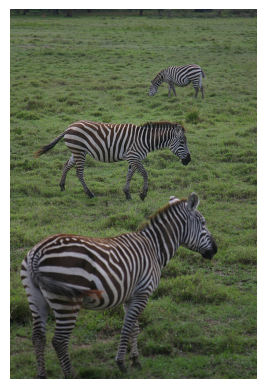

------------------------------
UTENTE: What is visible in this picture?
MINI-LLAVA: The picture shows a group of zebras standing in a field. The background is green and there are some trees in the distance. The zebras are standing in a line, facing towards the camera.
------------------------------


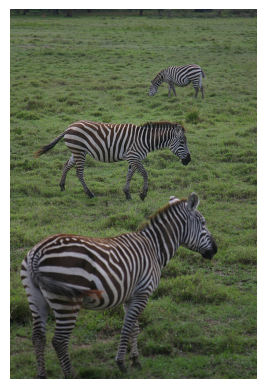

------------------------------
UTENTE: How many zebras can you count in this picture?
MINI-LLAVA: There are at least 10 zebras in this picture.
------------------------------


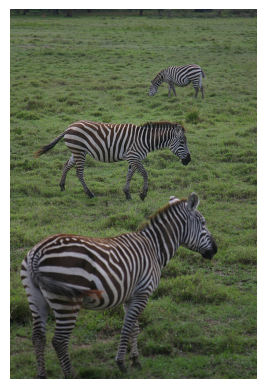

------------------------------
UTENTE: What are the zebras doing?
MINI-LLAVA: The zebras are grazing on the grassy field while the other animals are watching them. The grass is green and the sky is blue.
------------------------------


In [ ]:
import matplotlib.pyplot as plt

def interroga_minillava(image_path, user_question, model, max_new_tokens=50):
    model_final.eval() # Modalità valutazione (disattiva dropout/batchnorm)

    # 1. Caricamento e Visualizzazione Immagine
    raw_image = Image.open(image_path).convert("RGB")
    plt.imshow(raw_image)
    plt.axis('off')
    plt.show()

    # 2. Pre-processing Multimodale
    pixel_values = model_final.processor(images=raw_image, return_tensors="pt").pixel_values.to("cuda").to(torch.bfloat16)

    # Formattazione Prompt TinyLlama
    prompt = f"<|user|>\n{user_question}</s>\n<|assistant|>\n"
    inputs = model_final.tokenizer(prompt, return_tensors="pt").to("cuda")

    # 3. Generazione Risposta (Autoregressiva)
    with torch.no_grad():
        # Estraiamo le feature visive e proiettiamole
        zv = model_final.vision_encoder(pixel_values).last_hidden_state
        hv = model_final.mm_projector(zv)

        # Embeddings del testo del prompt
        text_embeds = model_final.llm.get_input_embeddings()(inputs.input_ids)

        # Unione: Immagine + Testo
        combined_embeds = torch.cat((hv, text_embeds), dim=1)

        # Generazione effettiva dei nuovi token
        output_ids = model_final.llm.generate(
            inputs_embeds=combined_embeds,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.2, #fondamentale per la precisione visiva
            top_p=0.9,
            pad_token_id=model_final.tokenizer.eos_token_id
        )

    # 4. Decodifica e Pulizia del testo
    response = model_final.tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("-" * 30)
    print(f"UTENTE: {user_question}")
    print(f"MINI-LLAVA: {response}")
    print("-" * 30)

# --- ESEMPIO DI UTILIZZO ---
test_img = "/content/COCO_train2014_000000000154.jpg"
interroga_minillava(test_img, "What is visible in this picture?", model_final)
interroga_minillava(test_img, "How many zebras can you count in this picture?", model_final)
interroga_minillava(test_img, "What are the zebras doing?", model_final)

In [ ]:
import random

def genera_report_per_giudice_ai(n_test=10):
    model_final.eval()
    report = []

    print("Agisci come un valutatore esperto di modelli AI multimodali. Valuta le risposte di 'MiniLLaVA' confrontandole con la 'RISPOSTA REALE' (Ground Truth). Dai un voto da 1 a 10 per Accuratezza e Utilità.\n")

    for i in range(n_test):
        # Scegliamo un esempio casuale
        idx = random.randint(0, len(train_ds_instruct)-1)
        item = train_ds_instruct[idx]

        # Prepariamo l'input visivo
        pixel_values = model_final.processor(images=item['image'], return_tensors="pt").pixel_values.to("cuda").to(torch.float32)

        # Estraiamo domanda e risposta reale dal prompt formattato
        raw_prompt = item['prompt']
        domanda = raw_prompt.split("<|user|>\n")[1].split("</s>")[0]
        risposta_reale = raw_prompt.split("<|assistant|>\n")[1].split("</s>")[0]

        # Generazione MiniLLaVA
        prompt_input = f"<|user|>\n{domanda}</s>\n<|assistant|>\n"
        inputs = model_final.tokenizer(prompt_input, return_tensors="pt").to("cuda")

        with torch.no_grad():
            zv = model_final.vision_encoder(pixel_values).last_hidden_state
            hv = model_final.mm_projector(zv)
            text_embeds = model_final.llm.get_input_embeddings()(inputs.input_ids)
            combined_embeds = torch.cat((hv, text_embeds), dim=1)

            output_ids = model_final.llm.generate(
                inputs_embeds=combined_embeds,
                max_new_tokens=40,
                do_sample=True,
                temperature=0.4,
                top_p=0.9
            )

        risposta_minillava = model_final.tokenizer.decode(output_ids[0], skip_special_tokens=True)

        blocco = f"""
TEST N. {i+1}
DOMANDA: {domanda}
RISPOSTA REALE (Ground Truth): {risposta_reale}
RISPOSTA MINI-LLAVA (Sotto Test): {risposta_minillava}
---"""
        print(blocco)
        report.append(blocco)

genera_report_per_giudice_ai(10)

Agisci come un valutatore esperto di modelli AI multimodali. Valuta le risposte di 'MiniLLaVA' confrontandole con la 'RISPOSTA REALE' (Ground Truth). Dai un voto da 1 a 10 per Accuratezza e Utilità.


TEST N. 1
DOMANDA: Is the dog holding an object in its mouth? If so, what is it?
RISPOSTA REALE (Ground Truth): Yes, the dog is holding a Frisbee in its mouth.
RISPOSTA MINI-LLAVA (Sotto Test): The dog is holding a toy or a ball in its mouth.
---

TEST N. 2
DOMANDA: How many clock towers are there in the image?
RISPOSTA REALE (Ground Truth): There are two clock towers in the image.
RISPOSTA MINI-LLAVA (Sotto Test): There are two clock towers in the image.
---

TEST N. 3
DOMANDA: What is the man wearing in the image?
RISPOSTA REALE (Ground Truth): The man in the image is wearing a white shirt.
RISPOSTA MINI-LLAVA (Sotto Test): The man in the image is wearing a white shirt and a black jacket.
---

TEST N. 4
DOMANDA: Is the man indoors or outdoors?
RISPOSTA REALE (Ground Truth): The man is i